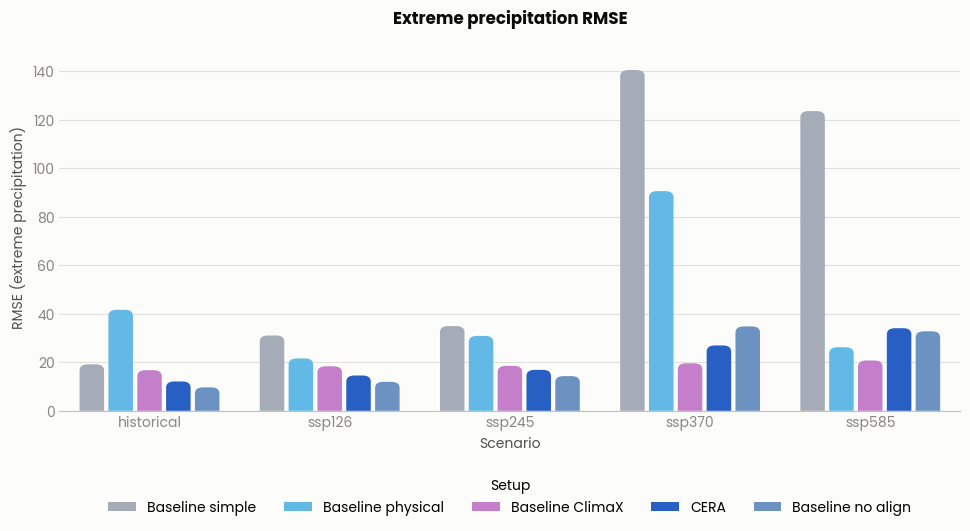

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Patch

# --- Typography (modern sans-serif, with safe fallbacks) ---
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Poppins", "Roboto", "Open Sans", "DejaVu Sans"]

# --- Data ---
df = pd.read_csv("../reportGraph/csv/rmse_extreme_precip_pr_mixhyper.csv")

scenario_order = ["historical", "ssp126", "ssp245", "ssp370", "ssp585"]
setup_order = ["Baseline simple", "Baseline physical", "Baseline ClimaX", "CERA", "Baseline no align"]
setups = [s for s in setup_order if s in df["setup"].unique()]

pivot = df.pivot(index="scenario", columns="setup", values="rmse_extreme").reindex(scenario_order)
pivot = pivot[setups]  # keep requested setup order for consistent color mapping

# --- Palette (categorical, fixed order — never re-cycled) ---
palette = ["#a6acb7", "#62b9e5", "#c57fca", "#275fc4", "#6b92c0"]
colors = palette[: len(setups)]

n_groups = len(pivot.index)
n_series = len(setups)
group_width = 0.8
slot_width = group_width / n_series
bar_gap = slot_width * 0.15  # small gap between bars within the same group
bar_width = slot_width - bar_gap
x = np.arange(n_groups)

# --- Figure ---
fig, ax = plt.subplots(figsize=(10, 5.5), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

# Fix the view limits *before* drawing so the corner radius (computed from
# pixel-to-data ratios) stays constant across every bar.
ax.set_xlim(x.min() - 0.5, x.max() + 0.5)
ax.set_ylim(0, pivot.values.max() * 1.08)


def rounded_top_bar(ax, xc, height, width, color, radius_px=7, **kwargs):
    """A bar with square base (anchored to the baseline) and softly
    rounded top corners, for a more modern look than a plain rectangle."""
    if height <= 0:
        return
    origin = ax.transData.transform((0, 0))
    rx = abs(ax.transData.inverted().transform((origin[0] + radius_px, origin[1]))[0])
    ry = abs(ax.transData.inverted().transform((origin[0], origin[1] + radius_px))[1])
    rx = min(rx, width / 2)
    ry = min(ry, height)

    left, right = xc - width / 2, xc + width / 2
    top, bottom = height, 0

    verts = [
        (left, bottom),
        (left, top - ry),
        (left, top),
        (left + rx, top),
        (right - rx, top),
        (right, top),
        (right, top - ry),
        (right, bottom),
        (left, bottom),
    ]
    codes = [
        Path.MOVETO,
        Path.LINETO,
        Path.CURVE3,
        Path.CURVE3,
        Path.LINETO,
        Path.CURVE3,
        Path.CURVE3,
        Path.LINETO,
        Path.CLOSEPOLY,
    ]
    ax.add_patch(PathPatch(Path(verts, codes), facecolor=color, linewidth=0, **kwargs))


for i, (setup, color) in enumerate(zip(setups, colors)):
    offset = (i - (n_series - 1) / 2) * slot_width
    for xi, value in zip(x, pivot[setup].values):
        rounded_top_bar(ax, xi + offset, value, bar_width, color)

# --- Axes & grid (recessive) ---
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, color="#0b0b0b")
ax.set_xlabel("Scenario", color="#52514e")
ax.set_ylabel("RMSE (extreme precipitation)", color="#52514e")
ax.set_title("Extreme precipitation RMSE", color="#0b0b0b", pad=14, fontweight="bold")

ax.yaxis.grid(True, color="#e1e0d9", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")
ax.tick_params(axis="both", colors="#898781", length=0)

# --- Legend (always present for ≥2 series) ---
legend_handles = [Patch(facecolor=c, label=s) for s, c in zip(setups, colors)]
ax.legend(
    handles=legend_handles,
    title="Setup",
    frameon=False,
    ncol=n_series,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Patch

# --- Typography (modern sans-serif, with safe fallbacks) ---
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Poppins", "Roboto", "Open Sans", "DejaVu Sans"]

# --- Data ---
df = pd.read_csv("../reportGraph/csv/rmse_global_by_scenario_pr_mixhyper.csv")

scenario_order = ["historical", "ssp126", "ssp245", "ssp370", "ssp585"]
setup_order = ["Baseline simple", "Baseline physical", "Baseline ClimaX", "CERA", "Baseline no align"]
setups = [s for s in setup_order if s in df["setup"].unique()]

pivot = df.pivot(index="scenario", columns="setup", values="rmse_extreme").reindex(scenario_order)
pivot = pivot[setups]  # keep requested setup order for consistent color mapping

# --- Palette (categorical, fixed order — never re-cycled) ---
palette = ["#a6acb7", "#62b9e5", "#c57fca", "#275fc4", "#6b92c0"]
colors = palette[: len(setups)]

n_groups = len(pivot.index)
n_series = len(setups)
group_width = 0.8
slot_width = group_width / n_series
bar_gap = slot_width * 0.15  # small gap between bars within the same group
bar_width = slot_width - bar_gap
x = np.arange(n_groups)

# --- Figure ---
fig, ax = plt.subplots(figsize=(10, 5.5), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

# Fix the view limits *before* drawing so the corner radius (computed from
# pixel-to-data ratios) stays constant across every bar.
ax.set_xlim(x.min() - 0.5, x.max() + 0.5)
ax.set_ylim(0, pivot.values.max() * 1.08)


def rounded_top_bar(ax, xc, height, width, color, radius_px=7, **kwargs):
    """A bar with square base (anchored to the baseline) and softly
    rounded top corners, for a more modern look than a plain rectangle."""
    if height <= 0:
        return
    origin = ax.transData.transform((0, 0))
    rx = abs(ax.transData.inverted().transform((origin[0] + radius_px, origin[1]))[0])
    ry = abs(ax.transData.inverted().transform((origin[0], origin[1] + radius_px))[1])
    rx = min(rx, width / 2)
    ry = min(ry, height)

    left, right = xc - width / 2, xc + width / 2
    top, bottom = height, 0

    verts = [
        (left, bottom),
        (left, top - ry),
        (left, top),
        (left + rx, top),
        (right - rx, top),
        (right, top),
        (right, top - ry),
        (right, bottom),
        (left, bottom),
    ]
    codes = [
        Path.MOVETO,
        Path.LINETO,
        Path.CURVE3,
        Path.CURVE3,
        Path.LINETO,
        Path.CURVE3,
        Path.CURVE3,
        Path.LINETO,
        Path.CLOSEPOLY,
    ]
    ax.add_patch(PathPatch(Path(verts, codes), facecolor=color, linewidth=0, **kwargs))


for i, (setup, color) in enumerate(zip(setups, colors)):
    offset = (i - (n_series - 1) / 2) * slot_width
    for xi, value in zip(x, pivot[setup].values):
        rounded_top_bar(ax, xi + offset, value, bar_width, color)

# --- Axes & grid (recessive) ---
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, color="#0b0b0b")
ax.set_xlabel("Scenario", color="#52514e")
ax.set_ylabel("RMSE (extreme precipitation)", color="#52514e")
ax.set_title("Extreme precipitation RMSE", color="#0b0b0b", pad=14, fontweight="bold")

ax.yaxis.grid(True, color="#e1e0d9", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")
ax.tick_params(axis="both", colors="#898781", length=0)

# --- Legend (always present for ≥2 series) ---
legend_handles = [Patch(facecolor=c, label=s) for s, c in zip(setups, colors)]
ax.legend(
    handles=legend_handles,
    title="Setup",
    frameon=False,
    ncol=n_series,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
)

plt.tight_layout()
plt.show()


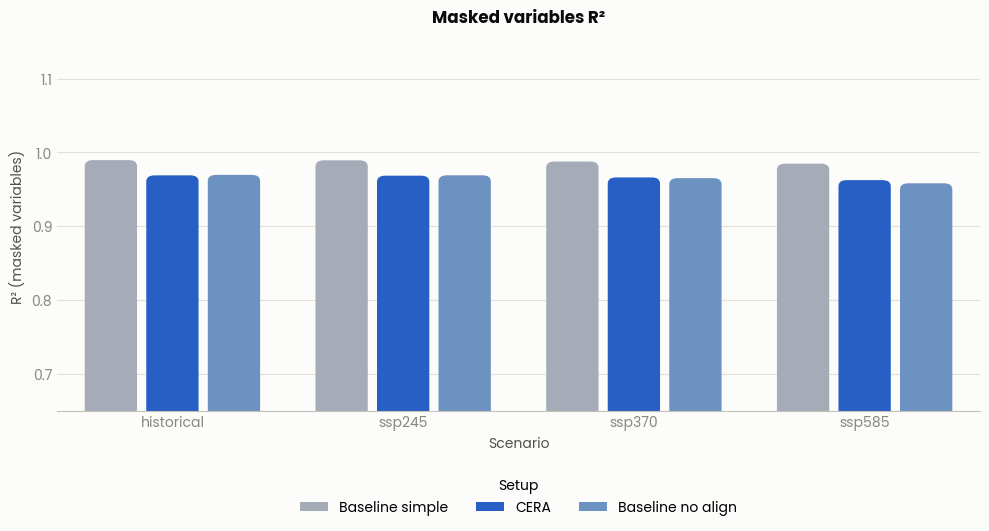

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Patch

# --- Typography (modern sans-serif, with safe fallbacks) ---
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Poppins", "Roboto", "Open Sans", "DejaVu Sans"]

# --- Data ---
df = pd.read_csv("../reportGraph/csv/r2_global_mean_by_scenario.csv")

scenario_order = ["historical", "ssp245", "ssp370", "ssp585"]
setup_order = ["Baseline simple", "CERA", "Baseline no align"]
setups = [s for s in setup_order if s in df["setup"].unique()]

# La colonne de valeurs dans ce CSV s'appelle "rmse_global" (et non "rmse_extreme")
pivot = df.pivot(index="scenario", columns="setup", values="r2_global_mean").reindex(scenario_order)
pivot = pivot[setups]  # keep requested setup order for consistent color mapping

# --- Palette (categorical, fixed order — never re-cycled) ---
palette = ["#a6acb7", "#275fc4", "#6b92c0"]
colors = palette[: len(setups)]

n_groups = len(pivot.index)
n_series = len(setups)
group_width = 0.8
slot_width = group_width / n_series
bar_gap = slot_width * 0.15  # small gap between bars within the same group
bar_width = slot_width - bar_gap
x = np.arange(n_groups)

# --- Figure ---
fig, ax = plt.subplots(figsize=(10, 5.5), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

# Fix the view limits *before* drawing so the corner radius (computed from
# pixel-to-data ratios) stays constant across every bar.
ax.set_xlim(x.min() - 0.5, x.max() + 0.5)
ax.set_ylim(0.65, 1.15)


def rounded_top_bar(ax, xc, height, width, color, radius_px=7, **kwargs):
    """A bar with square base (anchored to the baseline) and softly
    rounded top corners, for a more modern look than a plain rectangle."""
    if height <= 0:
        return
    origin = ax.transData.transform((0, 0))
    rx = abs(ax.transData.inverted().transform((origin[0] + radius_px, origin[1]))[0])
    ry = abs(ax.transData.inverted().transform((origin[0], origin[1] + radius_px))[1])
    rx = min(rx, width / 2)
    ry = min(ry, height)

    left, right = xc - width / 2, xc + width / 2
    top, bottom = height, 0

    verts = [
        (left, bottom),
        (left, top - ry),
        (left, top),
        (left + rx, top),
        (right - rx, top),
        (right, top),
        (right, top - ry),
        (right, bottom),
        (left, bottom),
    ]
    codes = [
        Path.MOVETO,
        Path.LINETO,
        Path.CURVE3,
        Path.CURVE3,
        Path.LINETO,
        Path.CURVE3,
        Path.CURVE3,
        Path.LINETO,
        Path.CLOSEPOLY,
    ]
    ax.add_patch(PathPatch(Path(verts, codes), facecolor=color, linewidth=0, **kwargs))


for i, (setup, color) in enumerate(zip(setups, colors)):
    offset = (i - (n_series - 1) / 2) * slot_width
    for xi, value in zip(x, pivot[setup].values):
        rounded_top_bar(ax, xi + offset, value, bar_width, color)

# --- Axes & grid (recessive) ---
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, color="#0b0b0b")
ax.set_xlabel("Scenario", color="#52514e")
ax.set_ylabel("R² (masked variables)", color="#52514e")
ax.set_title("Masked variables R²", color="#0b0b0b", pad=14, fontweight="bold")

ax.yaxis.grid(True, color="#e1e0d9", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")
ax.tick_params(axis="both", colors="#898781", length=0)

# --- Legend (always present for ≥2 series) ---
legend_handles = [Patch(facecolor=c, label=s) for s, c in zip(setups, colors)]
ax.legend(
    handles=legend_handles,
    title="Setup",
    frameon=False,
    ncol=n_series,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
)

plt.tight_layout()
plt.show()


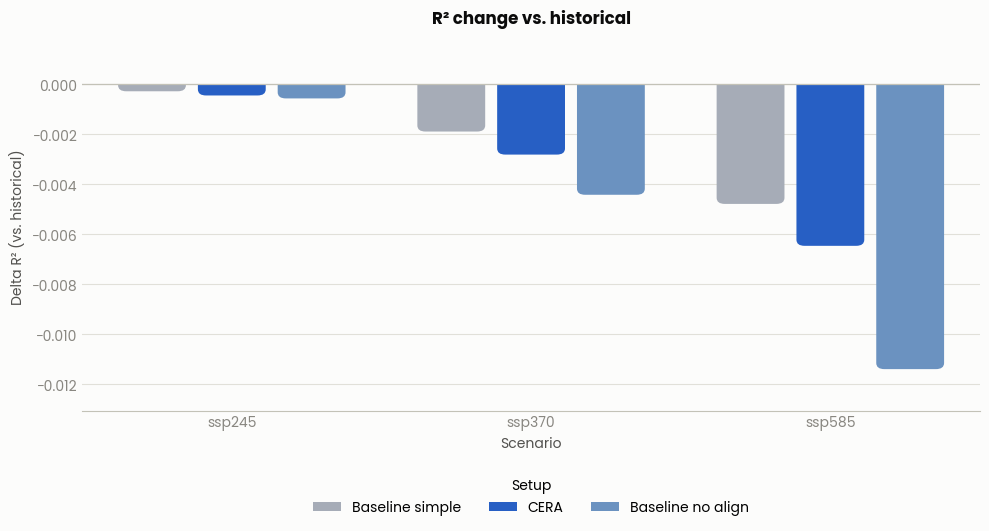

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Patch

# --- Typography (modern sans-serif, with safe fallbacks) ---
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Poppins", "Roboto", "Open Sans", "DejaVu Sans"]

# --- Data ---
df = pd.read_csv("../reportGraph/csv/delta_r2_global_mean_vs_historical.csv")

# Le CSV ne contient pas "historical" (c'est le scénario de référence, exclu à la génération)
scenario_order = ["ssp245", "ssp370", "ssp585"]
setup_order = ["Baseline simple", "CERA", "Baseline no align"]
setups = [s for s in setup_order if s in df["setup"].unique()]

pivot = df.pivot(index="scenario", columns="setup", values="delta_r2_global_mean").reindex(scenario_order)
pivot = pivot[setups]  # keep requested setup order for consistent color mapping

# --- Palette (categorical, fixed order — never re-cycled) ---
palette = ["#a6acb7", "#275fc4", "#6b92c0"]
colors = palette[: len(setups)]

n_groups = len(pivot.index)
n_series = len(setups)
group_width = 0.8
slot_width = group_width / n_series
bar_gap = slot_width * 0.15  # small gap between bars within the same group
bar_width = slot_width - bar_gap
x = np.arange(n_groups)

# --- Figure ---
fig, ax = plt.subplots(figsize=(10, 5.5), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

# Fix the view limits *before* drawing so the corner radius (computed from
# pixel-to-data ratios) stays constant across every bar.
ax.set_xlim(x.min() - 0.5, x.max() + 0.5)

_vmin = pivot.values.min()
_vmax = pivot.values.max()
_pad = (_vmax - _vmin) * 0.15 if _vmax > _vmin else abs(_vmin) * 0.15
ax.set_ylim(_vmin - _pad, max(_vmax, 0) + _pad)


def rounded_bar(ax, xc, height, width, color, radius_px=7, **kwargs):
    """A bar anchored at 0, with softly rounded corners on the tip end —
    works for both positive and negative heights."""
    if height == 0:
        return
    origin = ax.transData.transform((0, 0))
    rx = abs(ax.transData.inverted().transform((origin[0] + radius_px, origin[1]))[0])
    ry = abs(ax.transData.inverted().transform((origin[0], origin[1] + radius_px))[1])
    rx = min(rx, width / 2)
    ry = min(ry, abs(height))

    left, right = xc - width / 2, xc + width / 2
    base, tip = 0, height
    d = 1 if tip > base else -1  # direction from base to tip
    ry_signed = d * ry

    verts = [
        (left, base),
        (left, tip - ry_signed),
        (left, tip),
        (left + rx, tip),
        (right - rx, tip),
        (right, tip),
        (right, tip - ry_signed),
        (right, base),
        (left, base),
    ]
    codes = [
        Path.MOVETO,
        Path.LINETO,
        Path.CURVE3,
        Path.CURVE3,
        Path.LINETO,
        Path.CURVE3,
        Path.CURVE3,
        Path.LINETO,
        Path.CLOSEPOLY,
    ]
    ax.add_patch(PathPatch(Path(verts, codes), facecolor=color, linewidth=0, **kwargs))


for i, (setup, color) in enumerate(zip(setups, colors)):
    offset = (i - (n_series - 1) / 2) * slot_width
    for xi, value in zip(x, pivot[setup].values):
        rounded_bar(ax, xi + offset, value, bar_width, color)

# Ligne de référence à 0 (= même R² que l'historique)
ax.axhline(0, color="#c3c2b7", linewidth=0.9, zorder=1)

# --- Axes & grid (recessive) ---
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, color="#0b0b0b")
ax.set_xlabel("Scenario", color="#52514e")
ax.set_ylabel("Delta R\u00b2 (vs. historical)", color="#52514e")
ax.set_title("R\u00b2 change vs. historical", color="#0b0b0b", pad=14, fontweight="bold")

ax.yaxis.grid(True, color="#e1e0d9", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")
ax.tick_params(axis="both", colors="#898781", length=0)

# --- Legend (always present for ≥2 series) ---
legend_handles = [Patch(facecolor=c, label=s) for s, c in zip(setups, colors)]
ax.legend(
    handles=legend_handles,
    title="Setup",
    frameon=False,
    ncol=n_series,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
)

plt.tight_layout()
plt.show()


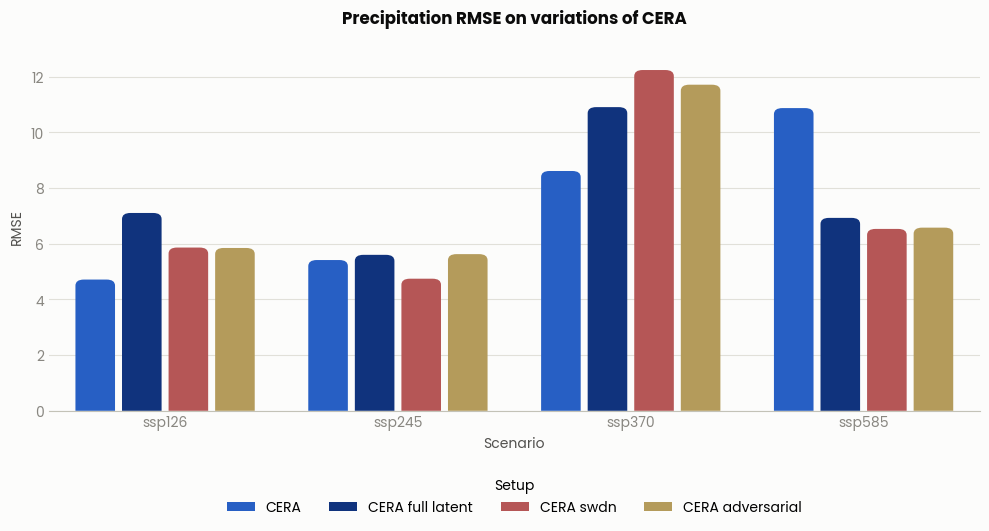

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Patch

# --- Typography (modern sans-serif, with safe fallbacks) ---
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Poppins", "Roboto", "Open Sans", "DejaVu Sans"]

# --- Data ---
df = pd.read_csv("../reportGraph/csv/rmse_global_by_scenario_pr_variants.csv")

# Le CSV ne contient pas "historical" (c'est le scénario de référence, ratio = 1 trivial)
scenario_order = ["ssp126", "ssp245", "ssp370", "ssp585"]
setup_order = ["CERA", "CERA full latent", "CERA swdn", "CERA adversarial"]
setups = [s for s in setup_order if s in df["setup"].unique()]

# La colonne de valeurs dans ce CSV s'appelle "rmse_ratio" (et non "rmse_global")
pivot = df.pivot(index="scenario", columns="setup", values="rmse_global").reindex(scenario_order)
pivot = pivot[setups]  # keep requested setup order for consistent color mapping

# --- Palette (categorical, fixed order — never re-cycled) ---
palette = ["#275fc4", "#10337d", "#b55656", "#b49b5b"]
colors = palette[: len(setups)]

n_groups = len(pivot.index)
n_series = len(setups)
group_width = 0.8
slot_width = group_width / n_series
bar_gap = slot_width * 0.15  # small gap between bars within the same group
bar_width = slot_width - bar_gap
x = np.arange(n_groups)

# --- Figure ---
fig, ax = plt.subplots(figsize=(10, 5.5), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

# Fix the view limits *before* drawing so the corner radius (computed from
# pixel-to-data ratios) stays constant across every bar.
ax.set_xlim(x.min() - 0.5, x.max() + 0.5)
ax.set_ylim(0, pivot.values.max() * 1.08)


def rounded_top_bar(ax, xc, height, width, color, radius_px=7, **kwargs):
    """A bar with square base (anchored to the baseline) and softly
    rounded top corners, for a more modern look than a plain rectangle."""
    if height <= 0:
        return
    origin = ax.transData.transform((0, 0))
    rx = abs(ax.transData.inverted().transform((origin[0] + radius_px, origin[1]))[0])
    ry = abs(ax.transData.inverted().transform((origin[0], origin[1] + radius_px))[1])
    rx = min(rx, width / 2)
    ry = min(ry, height)

    left, right = xc - width / 2, xc + width / 2
    top, bottom = height, 0

    verts = [
        (left, bottom),
        (left, top - ry),
        (left, top),
        (left + rx, top),
        (right - rx, top),
        (right, top),
        (right, top - ry),
        (right, bottom),
        (left, bottom),
    ]
    codes = [
        Path.MOVETO,
        Path.LINETO,
        Path.CURVE3,
        Path.CURVE3,
        Path.LINETO,
        Path.CURVE3,
        Path.CURVE3,
        Path.LINETO,
        Path.CLOSEPOLY,
    ]
    ax.add_patch(PathPatch(Path(verts, codes), facecolor=color, linewidth=0, **kwargs))


for i, (setup, color) in enumerate(zip(setups, colors)):
    offset = (i - (n_series - 1) / 2) * slot_width
    for xi, value in zip(x, pivot[setup].values):
        rounded_top_bar(ax, xi + offset, value, bar_width, color)


# --- Axes & grid (recessive) ---
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, color="#0b0b0b")
ax.set_xlabel("Scenario", color="#52514e")
ax.set_ylabel("RMSE", color="#52514e")
ax.set_title("Precipitation RMSE on variations of CERA", color="#0b0b0b", pad=14, fontweight="bold")

ax.yaxis.grid(True, color="#e1e0d9", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")
ax.tick_params(axis="both", colors="#898781", length=0)

# --- Legend (always present for ≥2 series) ---
legend_handles = [Patch(facecolor=c, label=s) for s, c in zip(setups, colors)]
ax.legend(
    handles=legend_handles,
    title="Setup",
    frameon=False,
    ncol=n_series,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
)

plt.tight_layout()
plt.show()


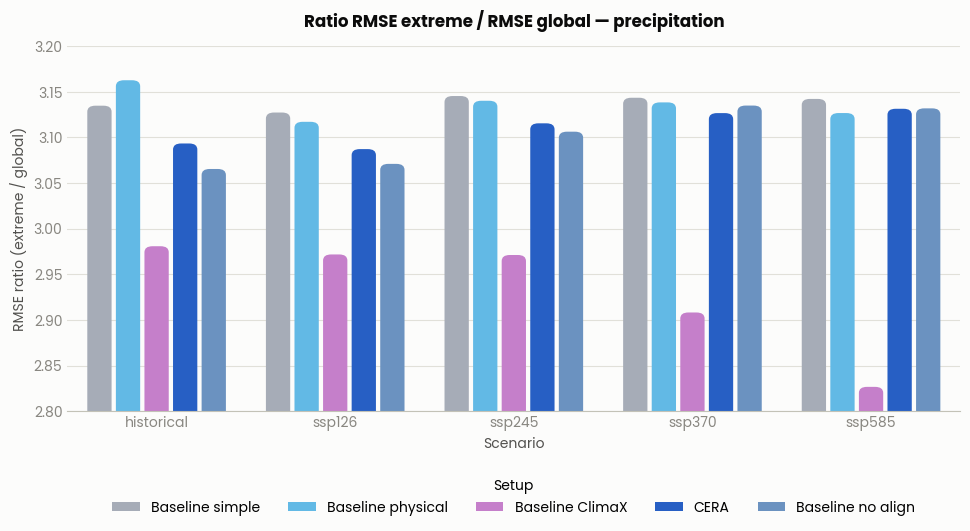

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Patch

# --- Typography (modern sans-serif, with safe fallbacks) ---
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Poppins", "Roboto", "Open Sans", "DejaVu Sans"]

# --- Data ---
df_global = pd.read_csv("../reportGraph/csv/rmse_global_by_scenario_pr_mixhyper.csv")
df_extreme = pd.read_csv("../reportGraph/csv/rmse_extreme_precip_pr_mixhyper.csv")

# Fusion sur (setup, scenario) puis calcul du ratio extreme / global
df_ratio = df_extreme.merge(df_global, on=["setup", "scenario"], how="inner")
df_ratio["rmse_ratio"] = df_ratio["rmse_extreme"] / df_ratio["rmse_global"]

scenario_order = ["historical", "ssp126", "ssp245", "ssp370", "ssp585"]
setup_order = ["Baseline simple", "Baseline physical", "Baseline ClimaX", "CERA", "Baseline no align"]
setups = [s for s in setup_order if s in df_ratio["setup"].unique()]

pivot = df_ratio.pivot(index="scenario", columns="setup", values="rmse_ratio").reindex(scenario_order)
pivot = pivot[setups]  # keep requested setup order for consistent color mapping

# --- Palette (categorical, fixed order — never re-cycled) ---
palette = ["#a6acb7", "#62b9e5", "#c57fca", "#275fc4", "#6b92c0"]
colors = palette[: len(setups)]

n_groups = len(pivot.index)
n_series = len(setups)
group_width = 0.8
slot_width = group_width / n_series
bar_gap = slot_width * 0.15  # small gap between bars within the same group
bar_width = slot_width - bar_gap
x = np.arange(n_groups)

# --- Figure ---
fig, ax = plt.subplots(figsize=(10, 5.5), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

# Fix the view limits *before* drawing so the corner radius (computed from
# pixel-to-data ratios) stays constant across every bar.
ax.set_xlim(x.min() - 0.5, x.max() + 0.5)
ax.set_ylim(2.8, 3.2)



def rounded_top_bar(ax, xc, height, width, color, radius_px=7, **kwargs):
    """A bar with square base (anchored to the baseline) and softly
    rounded top corners, for a more modern look than a plain rectangle."""
    if height <= 0:
        return
    origin = ax.transData.transform((0, 0))
    rx = abs(ax.transData.inverted().transform((origin[0] + radius_px, origin[1]))[0])
    ry = abs(ax.transData.inverted().transform((origin[0], origin[1] + radius_px))[1])
    rx = min(rx, width / 2)
    ry = min(ry, height)

    left, right = xc - width / 2, xc + width / 2
    top, bottom = height, 0

    verts = [
        (left, bottom),
        (left, top - ry),
        (left, top),
        (left + rx, top),
        (right - rx, top),
        (right, top),
        (right, top - ry),
        (right, bottom),
        (left, bottom),
    ]
    codes = [
        Path.MOVETO,
        Path.LINETO,
        Path.CURVE3,
        Path.CURVE3,
        Path.LINETO,
        Path.CURVE3,
        Path.CURVE3,
        Path.LINETO,
        Path.CLOSEPOLY,
    ]
    ax.add_patch(PathPatch(Path(verts, codes), facecolor=color, linewidth=0, **kwargs))


for i, (setup, color) in enumerate(zip(setups, colors)):
    offset = (i - (n_series - 1) / 2) * slot_width
    for xi, value in zip(x, pivot[setup].values):
        rounded_top_bar(ax, xi + offset, value, bar_width, color)

# --- Axes & grid (recessive) ---
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, color="#0b0b0b")
ax.set_xlabel("Scenario", color="#52514e")
ax.set_ylabel("RMSE ratio (extreme / global)", color="#52514e")
ax.set_title("Ratio RMSE extreme / RMSE global — precipitation", color="#0b0b0b", pad=14, fontweight="bold")

# Ligne de référence à ratio = 1 (extreme == global)
ax.axhline(1.0, color="#898781", linewidth=1.0, linestyle="--", zorder=1)

ax.yaxis.grid(True, color="#e1e0d9", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")
ax.tick_params(axis="both", colors="#898781", length=0)

# --- Legend (always present for ≥2 series) ---
legend_handles = [Patch(facecolor=c, label=s) for s, c in zip(setups, colors)]
ax.legend(
    handles=legend_handles,
    title="Setup",
    frameon=False,
    ncol=n_series,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
)

plt.tight_layout()
plt.show()


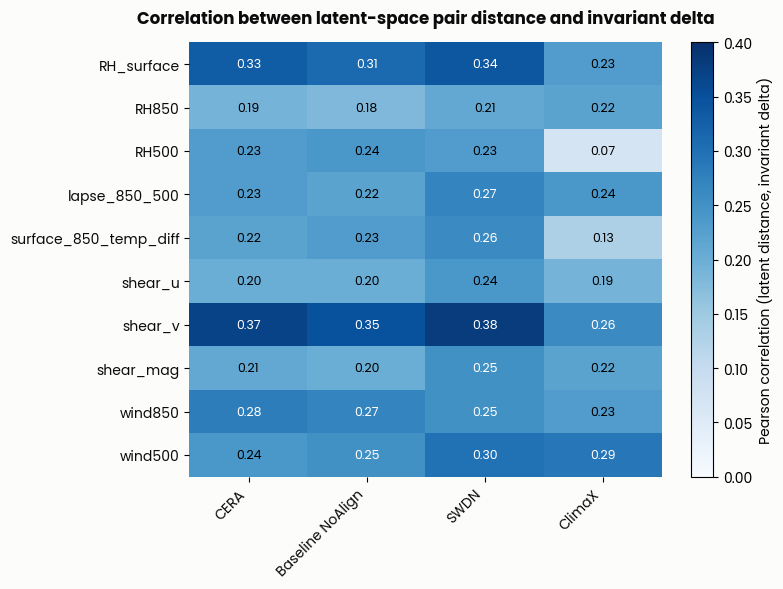

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Typography (modern sans-serif, with safe fallbacks) ---
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Poppins", "Roboto", "Open Sans", "DejaVu Sans"]

# --- Data ---
df = pd.read_csv("../reportGraph/csv/tableau_metrics.csv", index_col="Variable")

setups = list(df.columns)       # abscisse : setups CERA...
invariants = list(df.index)     # ordonnée : invariants RH...

# --- Figure ---
fig, ax = plt.subplots(figsize=(8, 6), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

VMIN, VMAX = 0, 0.4
im = ax.imshow(df.values, cmap="Blues", vmin=VMIN, vmax=VMAX, aspect="auto")

ax.set_xticks(np.arange(len(setups)))
ax.set_xticklabels(setups, rotation=45, ha="right", color="#0b0b0b")
ax.set_yticks(np.arange(len(invariants)))
ax.set_yticklabels(invariants, color="#0b0b0b")

# --- Value annotations (white text on dark cells for readability) ---
for i in range(df.shape[0]):
    for j in range(df.shape[1]):
        value = df.values[i, j]
        text_color = "white" if value > 0.6 * VMAX else "black"
        ax.text(j, i, f"{value:.2f}",
                 ha="center", va="center", color=text_color, fontsize=9)

# --- Colorbar & labels ---
cbar = plt.colorbar(im, ax=ax, label="Pearson correlation (latent distance, invariant delta)")

ax.set_title(
    "Correlation between latent-space pair distance and invariant delta",
    color="#0b0b0b", pad=14, fontweight="bold",
)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()
